In [174]:
%config InlineBackend.figure_format = 'retina'
from wealth_process_V_opt import *
from hedonic_game import *
from optim import *
from decimal import *
import pandas as pd
import seaborn as sns   
import warnings
import time

# Network of miner
## Solo versus PPLNS with no management fees

Consider a network of miners with hashpowers $$h_i\text{ }i = 1,\ldots, n$$ such that 
$$
H = \sum_i h_i = 1.
$$
We can randomize using the Dirichlet distribution
$$
(h_1,\ldots, h_n)\sim \text{Dirichlet}(\alpha)
$$


(array([1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([0.00648895, 0.03211458, 0.05774021, 0.08336583, 0.10899146,
        0.13461709, 0.16024272, 0.18586834, 0.21149397, 0.2371196 ,
        0.26274523, 0.28837085, 0.31399648, 0.33962211, 0.36524774,
        0.39087336, 0.41649899, 0.44212462, 0.46775025, 0.49337588,
        0.5190015 , 0.54462713, 0.57025276, 0.59587839, 0.62150401,
        0.64712964, 0.67275527, 0.6983809 , 0.72400652, 0.74963215,
        0.77525778]),
 <BarContainer object of 30 artists>)

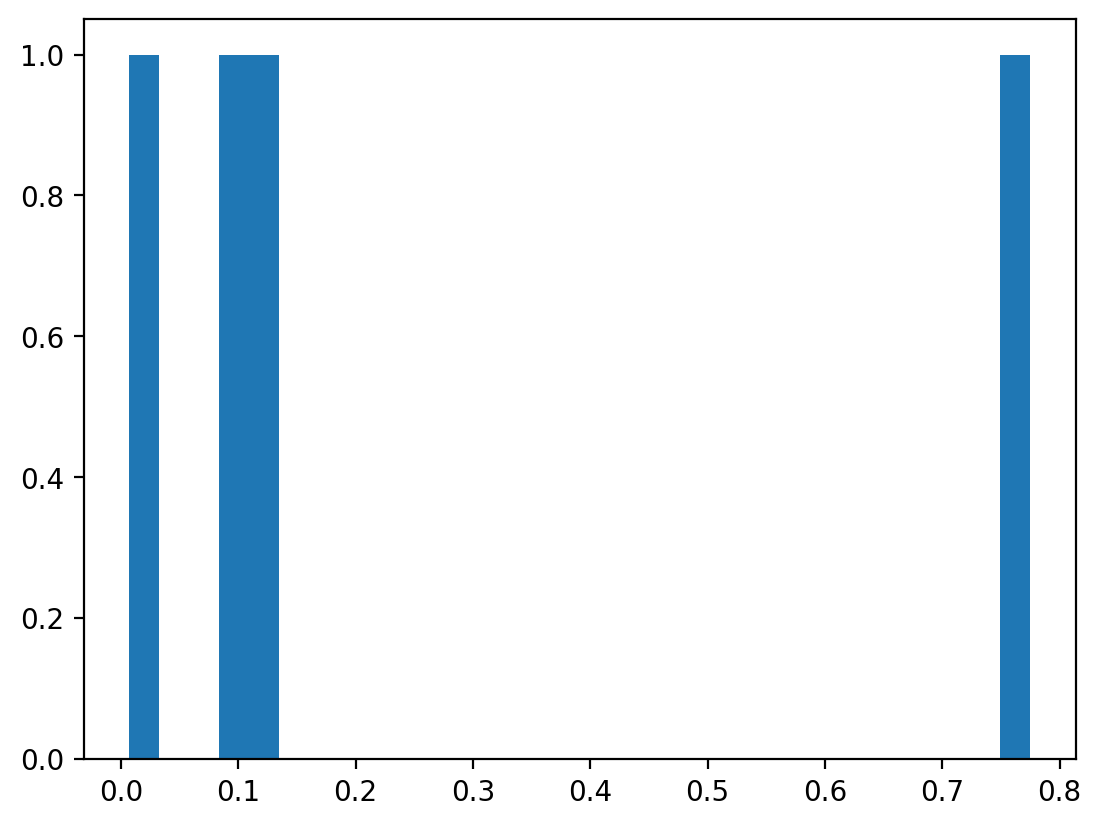

In [243]:
n = 4
Lam, b, q = 1, 3.125, 0.03 # block discovery rate of the network and reward for finding a block
alphas = np.ones(n) 
hs = np.random.dirichlet(alphas)
# hs = np.ones(n) / n 
plt.hist(hs, bins=30, density=False)

Then set the operational cost
$$
c = \mu b / (1 + \eta),
$$
Then set the initial wealth 
$$
x = \phi^{-1}(\beta)
$$

In [244]:
# etas = np.random.uniform(0.1, 0.3, n) # set the etas to 0.5 for all miners
etas = 0.1 * np.ones(n)  # set the etas to 0.5 for all miners
mus = hs * Lam
cs = mus * b / (1 + etas)
Xs_solo = [wealth_process(mu, b, c, 0, 1) for mu, c in zip(mus, cs)] # Define the wealth process for a solo miner 
# betas = np.random.uniform(0, 1, n)  # Define the ruin probability threshold
betas = 0.5*np.ones(n)  # Set the ruin probability threshold to 0.5 for all miners
xs = np.array([sc.optimize.root_scalar(lambda x: X_solo.ruin_proba(x) - beta, bracket=[0.001, 1000], method='bisect').root for X_solo, beta in zip(Xs_solo, betas)])
gammas = 0.1 * np.ones(n)  # Set the discount factors to 0.1 for all miners
div_solo = [X_solo.V(x, q)[1] for X_solo, x in zip(Xs_solo, xs)] # Compute the expected discounted dividends for a solo miner
div_solo

[11.247003546334511, 11.90832900002329, 11.182834334360967, 11.221492681494547]

For each miner there is an optimal pplns pool (with an optimal relative hahsrate). This depends on the fee function being applied and the shape of it. 

11.247003546334511
0.5433944862742432
11.90832900002329
0.0
11.182834334360967
0.6723761640279321
11.221492681494547
0.5909129291260337


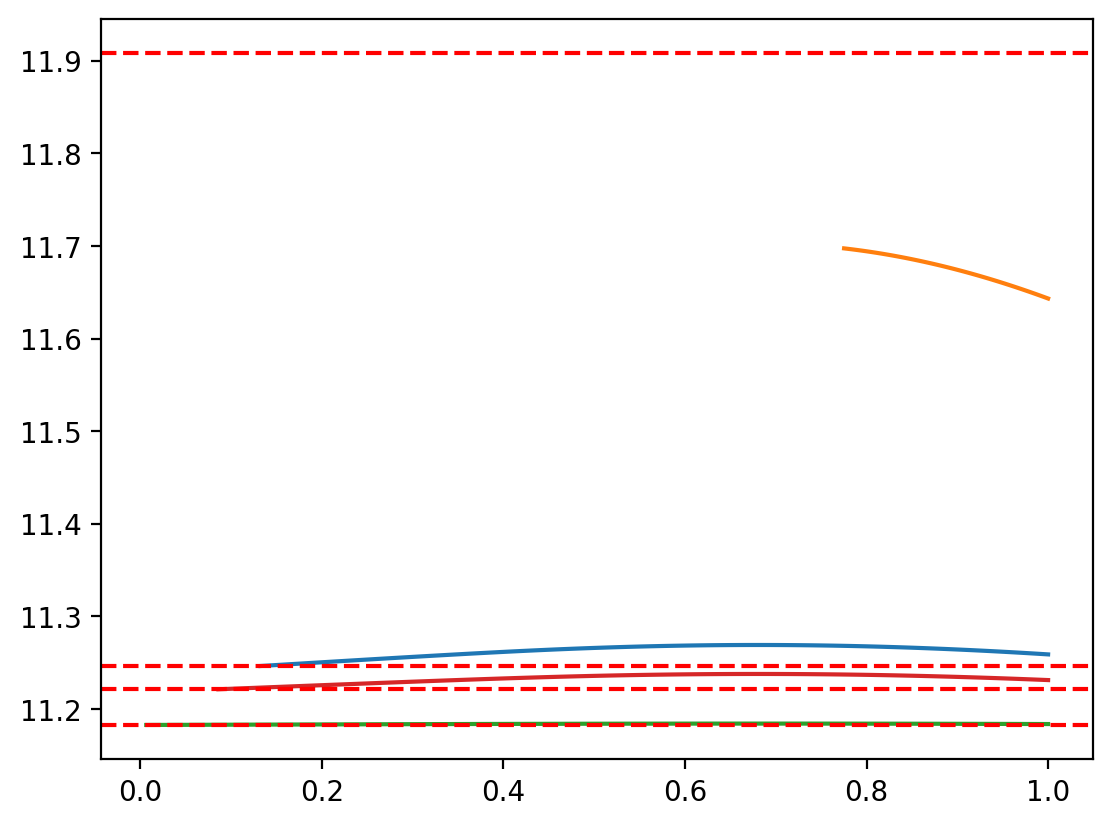

In [245]:
f0, fmax, theta = 0.00, 0.02, 2
fee_function=lambda H: f0 + (fmax - f0) * np.power(H, theta)
# fee_function = lambda H: np.piecewise(H, [H < 0.2, H >= 0.2],
#                          [0.0, 0.1])
# f = fee_function(env.H)

optimal_H = []
for h, c, x in zip(hs, cs, xs):
# k = 0
# h, c, x = hs[k], cs[k], xs[k]
    H_grid = np.linspace(0, sum(hs)-h, 100)
    Xs_pplns= [wealth_process(Lam * (H + h), b * h * (1 - fee_function(H+h)) / (H + h), c, 0, 1) for H in H_grid]
    X_solo = wealth_process(Lam * h, b, c, 0, 1)
    print(X_solo.V(x, q)[1])
    div = [X_pplns.V(x, q)[1] for X_pplns in Xs_pplns]
    plt.plot(H_grid + h, div) 
    plt.axhline(y=X_solo.V(x, q)[1], color='r', linestyle='--')
    print(H_grid[np.argmax(div)])


In [246]:
gammas = np.ones(n)
miners = [Miner(h=h, c =c, x=x, idx=i, gamma=gamma)
              for i, h, c, x, gamma in zip(np.arange(1, n + 1), hs, cs, xs, gammas)]
env = Environment(Lam=Lam, b=b, q=q, H=sum(m.h for m in miners))
solo = PPS_Pool(f=0.0, delta=1.0, name="solo")
game = Game(env, miners, {"solo": solo}, fee_function=fee_function,
                objective="dividend")
# game.set_initial_pplns_partition([[1],[2],[3],[4]], name_prefix="pplns")
game.assignment


{1: ('pps', 'solo'),
 2: ('pps', 'solo'),
 3: ('pps', 'solo'),
 4: ('pps', 'solo')}

In [247]:
def run_best_response(self, max_rounds: int = 1000, rng: Optional[random.Random] = None) -> bool:
    """Phase 2 (also reusable for Phase 1's aftermath): individual
    best-response to a fixed point. Returns True if it converged (Nash
    stable), False if max_rounds was hit -- treat that as 'possible cycle,
    inspect before trusting the result', not as a guarantee of instability."""
    rng = rng or random.Random(0)
    order = list(self.miners.values())
    for _ in range(max_rounds):
        rng.shuffle(order)
        changed = False
        for m in order:
            pps_freeriders = [
                self.miners[i]
                for i, a in self.assignment.items()
                if a[0] == "pps" and i != m.idx
                ]
            
            for pplns_partner in pps_freeriders:
            
                group  = [m, pplns_partner]
                H = sum(m.h for m in group)
                fee = self.fee_function(H) if len(group) >= 2 else 0.0
                gains = {}
                rate_m = self.env.Lam * H / self.env.H
                jump_m = self.env.b * (1 - fee) * m.h / H
                gains[m.idx] = self.engine.score(m, rate_m, jump_m) - self.current_payoff(m)
                rate_partner = self.env.Lam * H / self.env.H
                jump_partner = self.env.b * (1 - fee) * pplns_partner.h / H
                gains[pplns_partner.idx] = self.engine.score(pplns_partner, rate_partner, jump_partner) - self.current_payoff(pplns_partner)
                gains
                if all(g > 0 for g in gains.values()):
        
                    val = gains[m.idx]
                    name = f"pplns_{self._next_pool_id}"
                    self._next_pool_id += 1
                    self.pplns_pools[name] = PPLNS_Pool([], self.fee_function, name)
                    for miner in group:
                        self.move(miner, ("pplns", name))
                    changed = True
            target, val = self.best_response(m)
            if target != self.assignment[m.idx] and val > self.current_payoff(m):
                self.move(m, target)
                changed = True
        if not changed:
            return True
    return False

In [248]:
max_rounds = 10
rng = rng or random.Random(0)
order = list(game.miners.values())
for _ in range(max_rounds):
    rng.shuffle(order)
    changed = False
    for m in order:
        pps_freeriders = [
            game.miners[i]
            for i, a in game.assignment.items()
            if a[0] == "pps" and i != m.idx
            ]
        
        for pplns_partner in pps_freeriders:
        
            group  = [m, pplns_partner]
            H = sum(m.h for m in group)
            fee = game.fee_function(H) if len(group) >= 2 else 0.0
            gains = {}
            rate_m = game.env.Lam * H / game.env.H
            jump_m = game.env.b * (1 - fee) * m.h / H
            gains[m.idx] = game.engine.score(m, rate_m, jump_m) - game.current_payoff(m)
            rate_partner = game.env.Lam * H / game.env.H
            jump_partner = game.env.b * (1 - fee) * pplns_partner.h / H
            gains[pplns_partner.idx] = game.engine.score(pplns_partner, rate_partner, jump_partner) - game.current_payoff(pplns_partner)
            gains
            if all(g > 0 for g in gains.values()):
    
                val = gains[m.idx]
                name = f"pplns_{game._next_pool_id}"
                game._next_pool_id += 1
                game.pplns_pools[name] = PPLNS_Pool([], game.fee_function, name)
                for miner in group:
                    game.move(miner, ("pplns", name))
                changed = True
        target, val = game.best_response(m)
        if target != game.assignment[m.idx] and val > game.current_payoff(m):
            game.move(m, target)
            changed = True
changed, game.assignment    

(False,
 {1: ('pplns', 'pplns_0'),
  2: ('pps', 'solo'),
  3: ('pplns', 'pplns_0'),
  4: ('pplns', 'pplns_0')})

In [250]:
m = game.miners[2]
game.current_payoff(m)

11.90832900002329

In [234]:
m = game.miners[3]
target, val = game.best_response(m)
changed = False
if target != game.assignment[m.idx] and val > game.current_payoff(m):
    game.move(m, target)
    changed = True
if not changed:
    print(f"Miner {m.idx} has no profitable deviation.")
game.assignment

{1: ('pplns', 'pplns_1'),
 2: ('pplns', 'pplns_1'),
 3: ('pplns', 'pplns_1'),
 4: ('pplns', 'pplns_1')}

In [183]:
unpooled = [game.miners[i] for i, a in game.assignment.items() if a == ("pps", "solo")]
unpooled
game.propose_founding(unpooled)

True

In [185]:
game.assignment, [game.current_payoff(m) for m in game.miners.values()]

({1: ('pplns', 'pplns_0'),
  2: ('pplns', 'pplns_0'),
  3: ('pplns', 'pplns_0'),
  4: ('pplns', 'pplns_0')},
 [11.386371670767568,
  11.386371670767568,
  11.386371670767568,
  11.386371670767568])

In [168]:

rng = random.Random(0)
order = list(game.miners.values())
# for _ in range(max_rounds):
rng.shuffle(order)
changed = False
order
for m in order:
    print(game.assignment[m.idx], game.current_payoff(m))
# for m in order:
#     target, val = game.best_response(m)
#     if target != game.assignment[m.idx] and val > game.current_payoff(m):
#         game.move(m, target)
#         changed = True

('pplns', 'pplns_2') 11.323037743983306
('pplns', 'pplns_0') 11.323037743983306
('pplns', 'pplns_1') 11.323037743983306
('pplns', 'pplns_3') 11.323037743983306


In [169]:
m = order[0]
target, val = game.best_response(m)
target, val

(('pps', 'solo'), 11.323037743983306)

In [170]:
options = {t: game.payoff_at(m, t) for t in game.deviation_targets(m)}
target = max(options, key=options.get)
options, target, game.assignment[m.idx], game.current_payoff(m)

({('pps', 'solo'): 11.323037743983306},
 ('pps', 'solo'),
 ('pplns', 'pplns_2'),
 11.323037743983306)

In [171]:
targets = [("pps", name) for name in game.pps_pools]
targets += [("pplns", name) for name, pool in game.pplns_pools.items()]
targets

[('pps', 'solo'),
 ('pplns', 'pplns_0'),
 ('pplns', 'pplns_1'),
 ('pplns', 'pplns_2'),
 ('pplns', 'pplns_3')]

In [172]:
game.run_best_response(max_rounds = 10)
game.assignment


{1: ('pplns', 'pplns_0'),
 2: ('pplns', 'pplns_1'),
 3: ('pplns', 'pplns_2'),
 4: ('pplns', 'pplns_3')}

In [173]:
print(list(game.pplns_pools.values())[0].H, list(game.pplns_pools.values())[1].f)
np.array([m.h / list(game.pplns_pools.values())[0].H for m in list(game.pplns_pools.values())[0].members])

0.25 0.0


array([1.])

In [38]:
game.set_initial_pplns_partition([[1,2,3,4,5, 6, 10],[7,8,9]], name_prefix = "pplns")
game.assignment
print(list(game.pplns_pools.values())[0].H, list(game.pplns_pools.values())[1].f)

0.059207418125229214 0.02695422529802193


In [ ]:



# print(sum(np.array([X_solo.V(x, q)[1] for X_solo, x in zip(Xs_solo, xs)])
#       > np.array([X_pplns_full.V(x, q)[1] for X_pplns_full, x in zip(Xs_pplns_full, xs)])))

gammas = np.ones(n)
miners = [Miner(h=h, c =c, x=x, idx=i, gamma=gamma)
              for i, h, c, x, gamma in zip(np.arange(1, n + 1), hs, cs, xs, gammas)]
env = Environment(Lam=Lam, b=b, q=q, H=sum(m.h for m in miners))
solo = PPS_Pool(f=0.0, delta=1.0, name="solo")
# game = Game(env, miners, {"solo": solo}, 
#             fee_function=lambda H: f0 + (fmax - f0) * np.power(H / env.H, theta),
#             objective="dividend")

# --- initializing from a given partition instead of starting from solo ---
game = Game(env, miners, {"solo": solo}, fee_function=lambda H: 0.01 * H,
                objective="dividend")
game.set_initial_pplns_partition([[1, 2], [3, 4, 5], [6, 7, 8, 9, 10]], name_prefix="pplns")

fpps1, d1 = 0.04, 0.1
pps1 = PPS_Pool(f=fpps1, delta=d1, name="pps 1")
game.introduce_pps(pps1)
fpps2, d2 = 0.02, 0.14
pps2 = PPS_Pool(f=fpps2, delta=d2, name="pps 2")
game.introduce_pps(pps2)
fpps3, d3 = 0.0001, 0.4
pps3 = PPS_Pool(f=fpps3, delta=d3, name="pps 3")
game.introduce_pps(pps3)

In [2]:
n = 5
alphas = np.ones(n) 
np.random.seed(0)
hs = np.random.dirichlet(alphas)
Lam ,b = 1, 3.125 # block discovery rate of the network and reward for finding a block
mus = hs * Lam
# etas = np.random.uniform(0, 1, n) # random values for the etas
etas = np.random.uniform(0.1, 0.3, n) # set the etas to 0.5 for all miners
# etas = 0.1 * np.ones(n)  # set the etas to 0.5 for all miners
cs = mus * b / (1 + etas)
Xs_solo = [wealth_process(mu, b, c, 0, 1) for mu, c in zip(mus, cs)] # Define the wealth process for a solo miner 
betas = np.random.uniform(0, 1, n)  # Define the ruin probability threshold
# betas = 0.5*np.ones(n)  # Set the ruin probability threshold to 0.5 for all miners
xs = np.array([sc.optimize.root_scalar(lambda x: X_solo.ruin_proba(x) - beta, bracket=[0.001, 1000], method='bisect').root for X_solo, beta in zip(Xs_solo, betas)])
q = 0.03
divs_solo = np.array([X_solo.V(x, q)[1] for X_solo, x in zip(Xs_solo, xs)])
divs_solo-xs, hs, xs


(array([0.43652943, 0.6504819 , 0.90116407, 0.245166  , 0.19420131]),
 array([0.18451732, 0.29117779, 0.21404211, 0.18250647, 0.12775631]),
 array([ 1.70545752,  5.62019696,  3.4449242 ,  0.44948442, 24.68888501]))

(array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
        1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([0.12775631, 0.12939053, 0.13102474, 0.13265895, 0.13429317,
        0.13592738, 0.1375616 , 0.13919581, 0.14083003, 0.14246424,
        0.14409846, 0.14573267, 0.14736689, 0.1490011 , 0.15063532,
        0.15226953, 0.15390375, 0.15553796, 0.15717218, 0.15880639,
        0.16044061, 0.16207482, 0.16370904, 0.16534325, 0.16697746,
        0.16861168, 0.17024589, 0.17188011, 0.17351432, 0.17514854,
        0.17678275, 0.17841697, 0.18005118, 0.1816854 , 0.18331961,
        0.18495383, 0.18658804, 0.18822226, 0.18985647, 0.19149069,
      

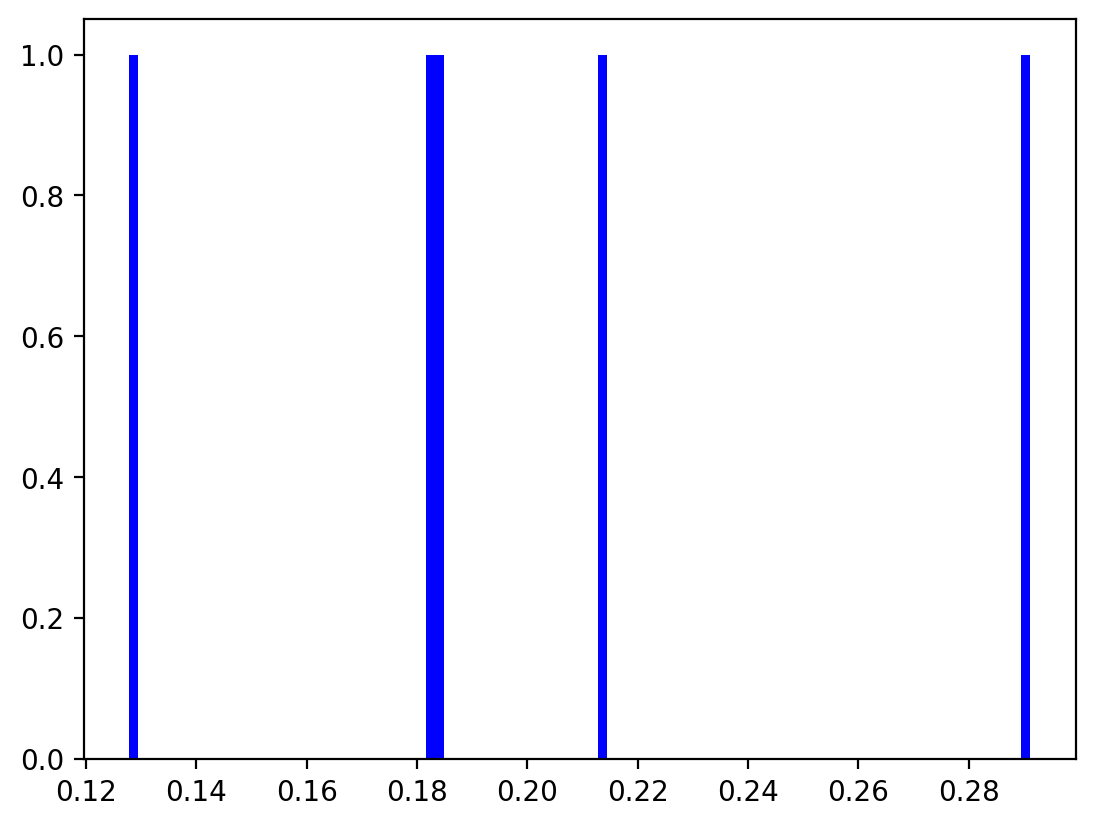

In [3]:
plt.hist(hs, bins=100, color='blue', label = 'Solo')

In [4]:
Xs_pplns = [wealth_process(Lam, b*h, c, 0, 1) for h, c in zip(hs, cs)]
divs_pplns = np.array([X_pplns.V(x, q, acc=0.01)[1] for X_pplns, x in zip(Xs_pplns, xs)])
divs_pplns

array([ 2.85849133,  6.88515431,  5.37805542,  1.38592618, 25.18086627])

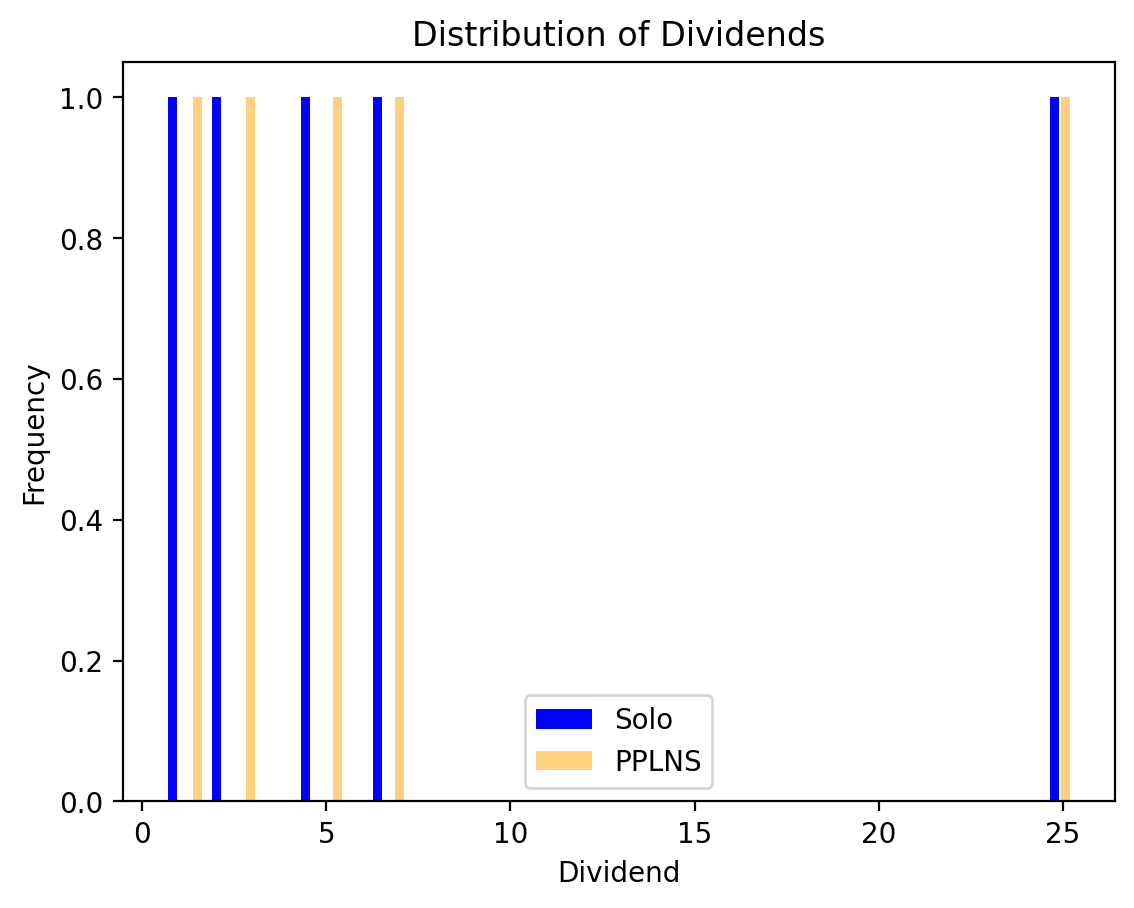

array([ True,  True,  True,  True,  True])

In [5]:
plt.hist(divs_solo, bins=100, color='blue', label = 'Solo')
plt.hist(divs_pplns, bins=100, color='orange', label = 'PPLNS', alpha=0.5)
plt.xlabel('Dividend')
plt.ylabel('Frequency')
plt.title('Distribution of Dividends')
plt.legend()
plt.show()
divs_solo < divs_pplns

# PPLNS mining pool formation depending on the management fees

Saved plot to ../figures/pool_fee_function_comparison.png

 x (share) |    Concave (gamma=0.5) |       Linear (gamma=1) | Power law / convex (gamma=2) |  log-concave
      1.0% |                 0.500% |                 0.050% |                 0.001% |       0.252%
      2.0% |                 0.707% |                 0.100% |                 0.002% |       0.473%
      5.0% |                 1.118% |                 0.250% |                 0.013% |       1.009%
     10.0% |                 1.581% |                 0.500% |                 0.050% |       1.652%
     20.0% |                 2.236% |                 1.000% |                 0.200% |       2.500%
     30.0% |                 2.739% |                 1.500% |                 0.450% |       3.074%
     50.0% |                 3.536% |                 2.500% |                 1.250% |       3.859%
    100.0% |                 5.000% |                 5.000% |                 5.000% |       5.000%


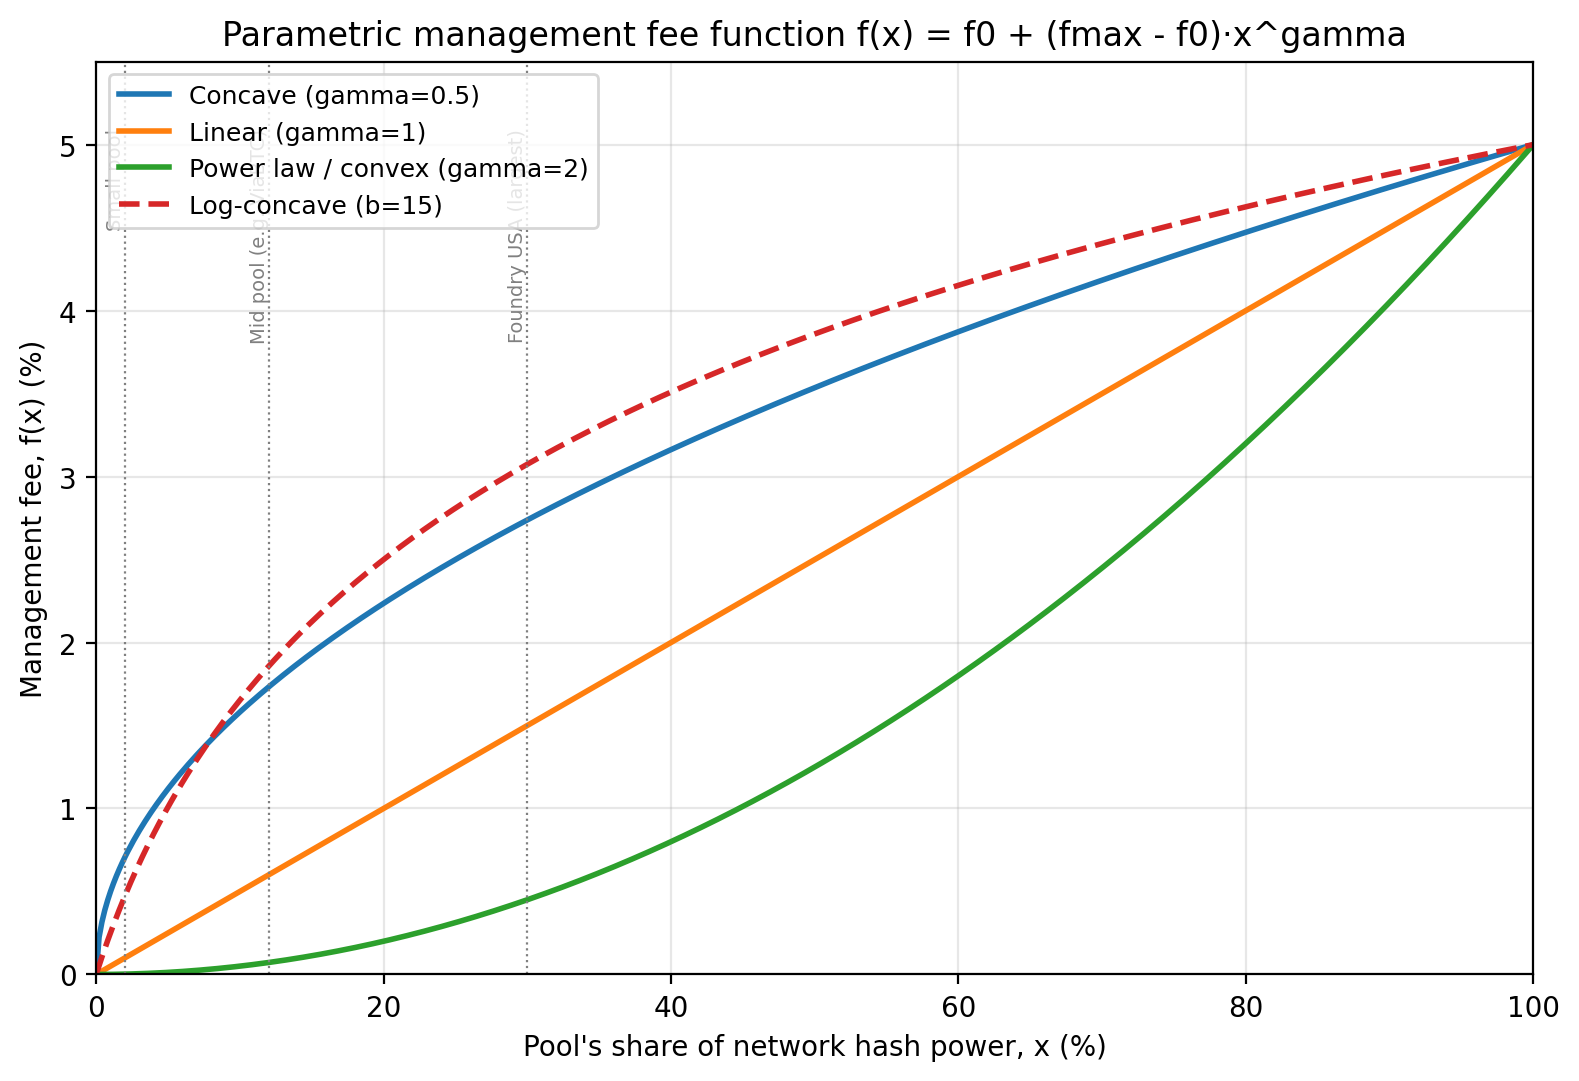

In [6]:
"""
Parametric management fee function for a Bitcoin mining pool,
increasing in the hash power the pool manages.

Single family that nests linear, concave, and power-law (convex)
shapes as special cases of one curvature parameter gamma:

    f(x; f0, fmax, gamma) = f0 + (fmax - f0) * x^gamma

where:
    x     = H / H_total, the pool's share of total network hash power, in [0, 1]
    f0    = fee charged to a pool with (near) zero hash power (baseline/fixed cost)
    fmax  = fee charged to a pool controlling all network hash power (upper bound)
    gamma = curvature parameter (> 0)
              gamma = 1        -> linear
              0 < gamma < 1    -> concave (diminishing marginal fee rate: economies of scale)
              gamma > 1        -> power law / convex (increasing marginal fee rate:
                                   penalizes concentration, e.g. a "decentralization tax")

An alternative concave specification (log-based, saturates fast) is also included
for comparison: f(x) = f0 + (fmax - f0) * log(1 + b*x) / log(1 + b).

All fees are fractions (0.01 = 1%). x=1 (100% of network hash power) is a
theoretical extreme included only to show the full shape of each curve.
"""

import numpy as np
import matplotlib.pyplot as plt

# ---- Parameters (edit these to calibrate) ----------------------------------
f0 = 0.00       # 0% fee floor for a negligible pool
fmax = 0.05     # 5% fee ceiling for a pool at 100% network hash power
gammas = {
    "Concave (gamma=0.5)": 0.5,
    "Linear (gamma=1)": 1.0,
    "Power law / convex (gamma=2)": 2.0,
}
log_b = 15  # steepness parameter for the alternative log-concave curve

# Real-world reference points for context (approx. network shares, mid-2026)
reference_pools = {
    "Small pool": 0.02,
    "Mid pool (e.g. ViaBTC)": 0.12,
    "Foundry USA (largest)": 0.30,
}

# ---- Fee functions -----------------------------------------------------------
def fee_power_family(x, f0, fmax, gamma):
    return f0 + (fmax - f0) * np.power(x, gamma)

def fee_log_concave(x, f0, fmax, b):
    return f0 + (fmax - f0) * np.log1p(b * x) / np.log1p(b)

# ---- Plot ---------------------------------------------------------------------
x = np.linspace(0, 1, 500)

fig, ax = plt.subplots(figsize=(8, 5.5))
for label, g in gammas.items():
    ax.plot(x * 100, fee_power_family(x, f0, fmax, g) * 100, label=label, linewidth=2)

ax.plot(x * 100, fee_log_concave(x, f0, fmax, log_b) * 100,
        label=f"Log-concave (b={log_b})", linewidth=2, linestyle="--")

for name, share in reference_pools.items():
    ax.axvline(share * 100, color="grey", linestyle=":", linewidth=0.8)
    ax.text(share * 100, ax.get_ylim()[1] if False else fmax * 100 * 1.02,
            name, rotation=90, fontsize=7, ha="right", va="top", color="grey")

ax.set_xlabel("Pool's share of network hash power, x (%)")
ax.set_ylabel("Management fee, f(x) (%)")
ax.set_title("Parametric management fee function f(x) = f0 + (fmax - f0)·x^gamma")
ax.set_xlim(0, 100)
ax.set_ylim(0, fmax * 100 * 1.1)
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("../figures/pool_fee_function_comparison.png", dpi=150)
print("Saved plot to ../figures/pool_fee_function_comparison.png")

# ---- Sample values table -------------------------------------------------------
sample_x = np.array([0.01, 0.02, 0.05, 0.10, 0.20, 0.30, 0.50, 1.00])
print(f"\n{'x (share)':>10} | " + " | ".join(f"{k:>22}" for k in gammas) + f" | {'log-concave':>12}")
for xv in sample_x:
    vals = [fee_power_family(xv, f0, fmax, g) for g in gammas.values()]
    log_val = fee_log_concave(xv, f0, fmax, log_b)
    row = " | ".join(f"{v*100:21.3f}%" for v in vals)
    print(f"{xv*100:9.1f}% | {row} | {log_val*100:11.3f}%")

# 1 PPLNS mining pools with 5% fee

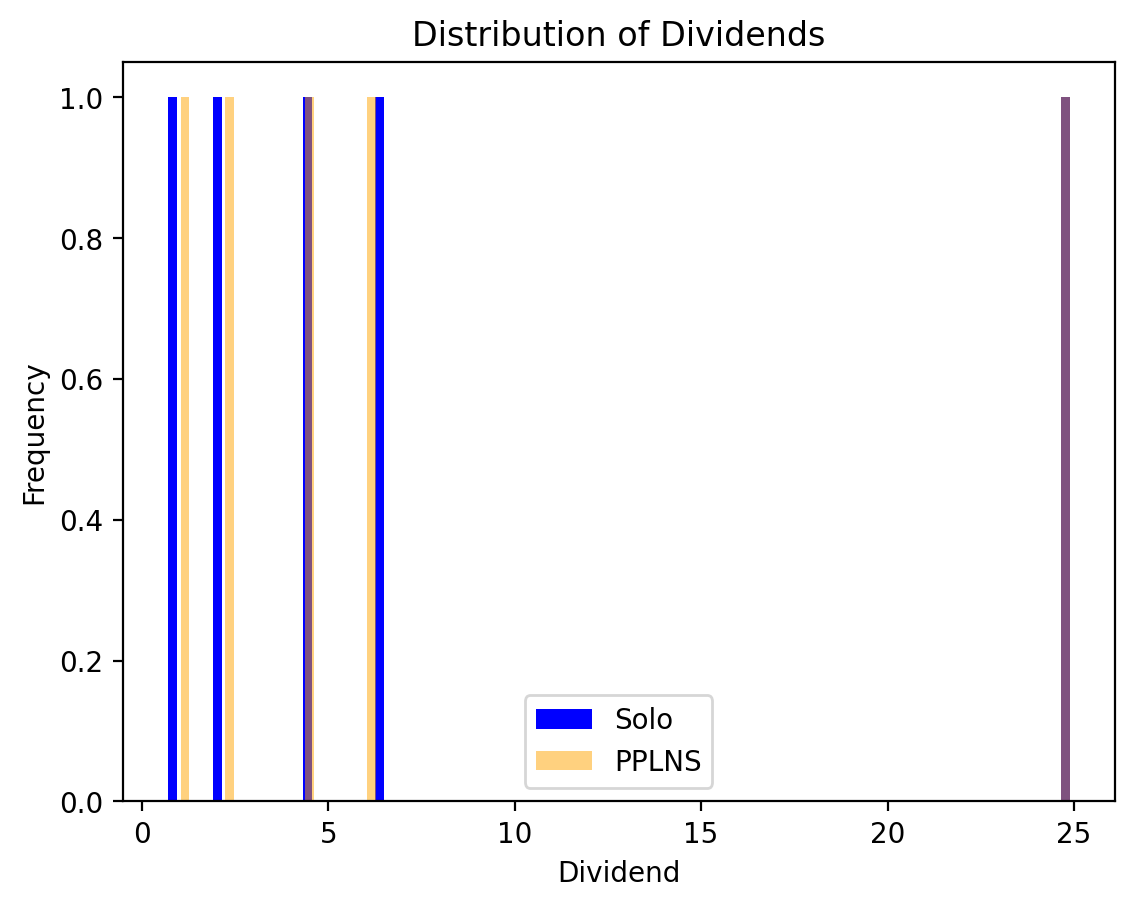

array([ True, False,  True,  True,  True])

In [7]:
x, f0, fmax, gamma = 1, 0.00, 0.05, 1.0
f = fee_power_family(x, f0, fmax, gamma)
Xs_pplns = [wealth_process(Lam, (1-f)*b*h, c, 0, 1) for h, c in zip(hs, cs)]
divs_pplns = np.array([X_pplns.V(x, q, acc=0.01)[1] for X_pplns, x in zip(Xs_pplns, xs)])
divs_pplns > divs_solo
plt.hist(divs_solo, bins=100, color='blue', label = 'Solo')
plt.hist(divs_pplns, bins=100, color='orange', label = 'PPLNS', alpha=0.5)
plt.xlabel('Dividend')
plt.ylabel('Frequency')
plt.title('Distribution of Dividends')
plt.legend()
plt.show()
divs_solo < divs_pplns


# Optimal mining pool formation

Sequential approach we add one miner at a time to the network. 

We define a class miner. Each object is characterized by a hashpower $h$, an operational cost $c$, and a initial wealth $x$. We know whether the miner has joined the network via in_network and what is the hashpower allocation $w$.

In [2]:
 
import random
from typing import Callable, Dict, List, Optional, Tuple
 
 
# ---------------------------------------------------------------------------
# Building blocks
# ---------------------------------------------------------------------------
 
class Miner:
    def __init__(self, h: float, c: float, x: float, idx: int, gamma: float = None):
        self.h = h
        self.c = c
        self.x = x          # initial reserve, used by the ruin-theoretic dividend objective
        self.gamma = gamma  # risk aversion, used by the mean-variance objective
        self.idx = idx
 
 
class PPS_Pool:
    """Also used to represent solo mining: PPS_Pool(f=0.0, delta=1.0, name='solo')."""
    __slots__ = ("f", "delta", "name")
 
    def __init__(self, f: float = 0.0, delta: float = 1.0, name: str = None):
        self.f = f
        self.delta = delta
        self.name = name
 
 
class PPLNS_Pool:
    __slots__ = ("members", "H", "fee_function", "f", "name")
 
    def __init__(self, members: List[Miner], fee_function: Callable[[float], float], name: str):
        self.members = set(members) if members else set()
        self.H = sum(m.h for m in self.members)
        self.fee_function = fee_function
        self.name = name
        self.f = self._price()
 
    def _price(self) -> float:
        # k == 1 (or 0) is the solo boundary case: no coordination, no fee.
        return 0.0 if len(self.members) <= 1 else self.fee_function(self.H)
 
    def add(self, miner: Miner) -> None:
        self.members.add(miner)
        self.H += miner.h
        self.f = self._price()
 
    def remove(self, miner: Miner) -> None:
        self.members.discard(miner)
        self.H -= miner.h
        self.f = self._price()
 
 
class Environment:
    """Blockchain / network primitives. Same role as your blockchain_network,
    trimmed to what the payoff engine needs."""
 
    def __init__(self, Lam: float, b: float, q: float, H: float):
        self.Lam = Lam   # network-wide block arrival rate
        self.b = b       # block reward
        self.q = q       # discount rate (dividend objective)
        self.H = H       # total network hashrate
 

In [3]:

# ---------------------------------------------------------------------------
# Payoff engine: turns a (miner, target) pair into a scalar score, without
# mutating anything. Both objectives share the same (rate, jump) primitives
# of the underlying compound-Poisson payout process.
# ---------------------------------------------------------------------------
 
class PayoffEngine:
    def __init__(self, env: Environment, objective: str, wealth_process_cls=None):
        assert objective in ("dividend", "mean_variance")
        self.env = env
        self.objective = objective
        self.wealth_process_cls = wealth_process_cls  # required only for 'dividend'
 
    def moments_pps(self, miner: Miner, pool: PPS_Pool) -> Tuple[float, float]:
        env = self.env
        rate = env.Lam * miner.h / env.H / pool.delta
        jump = env.b * (1 - pool.f) * pool.delta
        return rate, jump
 
    def moments_pplns(self, miner: Miner, pool: PPLNS_Pool) -> Tuple[float, float]:
        env = self.env
        already = miner in pool.members
        H_pool = pool.H if already else pool.H + miner.h
        k = len(pool.members) if already else len(pool.members) + 1
        fee = 0.0 if k <= 1 else pool.fee_function(H_pool)
        rate = env.Lam * H_pool / env.H
        jump = env.b * (1 - fee) * miner.h / H_pool
        return rate, jump
 
    def score(self, miner: Miner, rate: float, jump: float) -> float:
        if self.objective == "mean_variance":
            mean, var = rate * jump, rate * jump ** 2
            gamma = miner.gamma or 0.0
            return mean - miner.c * miner.h - 0.5 * gamma * var
        # dividend objective: plug in your ruin-theoretic wealth process
        wp = wealth_process(rate, jump, miner.c, 0, 1)
        return wp.V(miner.x, self.env.q)[1]

In [4]:
# ---------------------------------------------------------------------------
# Game orchestrator: owns all mutable state and the two-phase dynamics.
# ---------------------------------------------------------------------------
 
class Game:
    def __init__(self, env: Environment, miners: List[Miner], pps_pools: Dict[str, PPS_Pool],
                 fee_function: Callable[[float], float], objective: str,
                 wealth_process_cls=None):
        assert "solo" in pps_pools, "include PPS_Pool(f=0.0, delta=1.0, name='solo') in pps_pools"
        self.env = env
        self.miners = {m.idx: m for m in miners}
        self.pps_pools = dict(pps_pools)
        self.pplns_pools: Dict[str, PPLNS_Pool] = {}
        self.fee_function = fee_function
        self.engine = PayoffEngine(env, objective, wealth_process_cls)
        self.assignment: Dict[int, Tuple[str, str]] = {m.idx: ("pps", "solo") for m in miners}
        self._next_pool_id = 0
 
    # -- pure evaluation, no mutation --
 
    def payoff_at(self, miner: Miner, target: Tuple[str, str]) -> float:
        kind, name = target
        if kind == "pps":
            rate, jump = self.engine.moments_pps(miner, self.pps_pools[name])
        else:
            rate, jump = self.engine.moments_pplns(miner, self.pplns_pools[name])
        return self.engine.score(miner, rate, jump)
 
    def current_payoff(self, miner: Miner) -> float:
        return self.payoff_at(miner, self.assignment[miner.idx])
 
    def deviation_targets(self, miner: Miner) -> List[Tuple[str, str]]:
        """Unilateral, open-enrollment moves only: any PPS contract, or any
        EXISTING pplns pool with >=2 members. Founding a pool from scratch is
        handled separately -- see propose_founding."""
        targets = [("pps", name) for name in self.pps_pools]
        targets += [("pplns", name) for name, pool in self.pplns_pools.items()
                    if len(pool.members) >= 2]
        return targets
 
    def best_response(self, miner: Miner) -> Tuple[Tuple[str, str], float]:
        options = {t: self.payoff_at(miner, t) for t in self.deviation_targets(miner)}
        target = max(options, key=options.get)
        return target, options[target]
 
    # -- mutation --
 
    def move(self, miner: Miner, target: Tuple[str, str]) -> None:
        old_kind, old_name = self.assignment[miner.idx]
        if old_kind == "pplns":
            pool = self.pplns_pools[old_name]
            pool.remove(miner)
            if not pool.members:
                del self.pplns_pools[old_name]
        self.assignment[miner.idx] = target
        if target[0] == "pplns":
            self.pplns_pools[target[1]].add(miner)
 
    def propose_founding(self, group: List[Miner]) -> bool:
        """Coordinator proposes that `group` (typically 2 currently-solo/PPS
        miners) found a new PPLNS pool together. Accepted iff every member
        strictly gains relative to their current payoff."""
        H = sum(m.h for m in group)
        fee = self.fee_function(H) if len(group) >= 2 else 0.0
        gains = {}
        for m in group:
            rate = self.env.Lam * H / self.env.H
            jump = self.env.b * (1 - fee) * m.h / H
            gains[m.idx] = self.engine.score(m, rate, jump) - self.current_payoff(m)
        if all(g > 0 for g in gains.values()):
            name = f"pplns_{self._next_pool_id}"
            self._next_pool_id += 1
            self.pplns_pools[name] = PPLNS_Pool([], self.fee_function, name)
            for m in group:
                self.move(m, ("pplns", name))
            return True
        return False
 
    # -- dynamics --
 
    def run_formation(self, max_rounds: int = 1000, rng: Optional[random.Random] = None) -> None:
        """Phase 1: repeatedly propose pairwise foundings among currently
        unpooled miners until none improve. Order-dependent by construction --
        pass an rng for reproducibility, or call with different seeds to check
        how much the terminal partition depends on proposal order."""
        rng = rng or random.Random(0)
        for _ in range(max_rounds):
            unpooled = [self.miners[i] for i, a in self.assignment.items() if a == ("pps", "solo")]
            if len(unpooled) < 2:
                break
            rng.shuffle(unpooled)
            improved = False
            for a, b in zip(unpooled[::2], unpooled[1::2]):
                if self.propose_founding([a, b]):
                    improved = True
            if not improved:
                break
            
    def set_initial_pplns_partition(self, groups: List[List[int]], name_prefix: str = "pplns") -> None:
        """Seed an initial PPLNS partition directly, bypassing propose_founding.
        Call this right after constructing the Game, before running any dynamics.
 
        `groups` is a list of miner-idx lists, e.g. [[1, 2], [3, 4, 5]] -- each
        idx must appear in at most one group. Singleton groups are harmless
        (they just get fee 0, same as leaving that miner out). Any miner not
        listed in any group stays on ('pps', 'solo').
 
        Typical uses:
          - skip formation and start best-response dynamics from a partition
            you already have in mind (e.g. an observed real-world partition)
          - seed a candidate equilibrium and call is_nash_stable() immediately,
            with no dynamics run at all, to check it directly
        """
        seen = set()
        for group_idx in groups:
            overlap = seen & set(group_idx)
            assert not overlap, f"miner(s) {overlap} appear in more than one group"
            seen |= set(group_idx)
            members = [self.miners[i] for i in group_idx]
            name = f"{name_prefix}_{self._next_pool_id}"
            self._next_pool_id += 1
            pool = PPLNS_Pool(members, self.fee_function, name)
            self.pplns_pools[name] = pool
            for m in members:
                self.assignment[m.idx] = ("pplns", name)
 
    def run_best_response(self, max_rounds: int = 1000, rng: Optional[random.Random] = None) -> bool:
        """Phase 2 (also reusable for Phase 1's aftermath): individual
        best-response to a fixed point. Returns True if it converged (Nash
        stable), False if max_rounds was hit -- treat that as 'possible cycle,
        inspect before trusting the result', not as a guarantee of instability."""
        rng = rng or random.Random(0)
        order = list(self.miners.values())
        for _ in range(max_rounds):
            rng.shuffle(order)
            changed = False
            for m in order:
                target, val = self.best_response(m)
                if target != self.assignment[m.idx] and val > self.current_payoff(m):
                    self.move(m, target)
                    changed = True
            if not changed:
                return True
        return False
 
    def is_nash_stable(self) -> bool:
        return all(self.best_response(m)[0] == self.assignment[m.idx] for m in self.miners.values())
 
    def introduce_pps(self, pool: PPS_Pool) -> None:
        """The exogenous entrant shock -- terms assumed attractive, not
        optimised here. Call run_best_response() again afterward."""
        self.pps_pools[pool.name] = pool
 
 

In [39]:
n = 10
Lam, b, q = 1, 3.125, 0.03 # block discovery rate of the network and reward for finding a block
alphas = np.ones(n) * 1/2
hs = np.random.dirichlet(alphas)
print(hs)
etas = np.random.uniform(0.1, 0.3, n) # set the etas to 0.5 for all miners
# etas = 0.1 * np.ones(n)  # set the etas to 0.5 for all miners
mus = hs * Lam
cs = mus * b / (1 + etas)
Xs_solo = [wealth_process(mu, b, c, 0, 1) for mu, c in zip(mus, cs)] # Define the wealth process for a solo miner 
betas = np.random.uniform(0, 1, n)  # Define the ruin probability threshold

# betas = 0.5*np.ones(n)  # Set the ruin probability threshold to 0.5 for all miners
xs = np.array([sc.optimize.root_scalar(lambda x: X_solo.ruin_proba(x) - beta, bracket=[0.001, 1000], method='bisect').root for X_solo, beta in zip(Xs_solo, betas)])

f0, fmax, theta = 0.00, 0.05, 2
fee_function=lambda H: f0 + (fmax - f0) * np.power(H / env.H, theta)
# f = fee_function(env.H)
Xs_pplns_full = [wealth_process(Lam, b * h * (1 - fmax), c, 0, 1) for h, c in zip(hs, cs)]

# print(sum(np.array([X_solo.V(x, q)[1] for X_solo, x in zip(Xs_solo, xs)])
#       > np.array([X_pplns_full.V(x, q)[1] for X_pplns_full, x in zip(Xs_pplns_full, xs)])))

gammas = np.ones(n)
miners = [Miner(h=h, c =c, x=x, idx=i, gamma=gamma)
              for i, h, c, x, gamma in zip(np.arange(1, n + 1), hs, cs, xs, gammas)]
env = Environment(Lam=Lam, b=b, q=q, H=sum(m.h for m in miners))
solo = PPS_Pool(f=0.0, delta=1.0, name="solo")
# game = Game(env, miners, {"solo": solo}, 
#             fee_function=lambda H: f0 + (fmax - f0) * np.power(H / env.H, theta),
#             objective="dividend")

# --- initializing from a given partition instead of starting from solo ---
game = Game(env, miners, {"solo": solo}, fee_function=lambda H: 0.01 * H,
                objective="dividend")
game.set_initial_pplns_partition([[1, 2], [3, 4, 5], [6, 7, 8, 9, 10]], name_prefix="pplns")

fpps1, d1 = 0.04, 0.1
pps1 = PPS_Pool(f=fpps1, delta=d1, name="pps 1")
game.introduce_pps(pps1)
fpps2, d2 = 0.02, 0.14
pps2 = PPS_Pool(f=fpps2, delta=d2, name="pps 2")
game.introduce_pps(pps2)
fpps3, d3 = 0.0001, 0.4
pps3 = PPS_Pool(f=fpps3, delta=d3, name="pps 3")
game.introduce_pps(pps3)

[0.12134908 0.15071806 0.19994222 0.00566966 0.07124377 0.13385329
 0.16015953 0.01097507 0.05462893 0.09146038]


0.7617104833918827
0.7626838551125212
0.7638026266510377


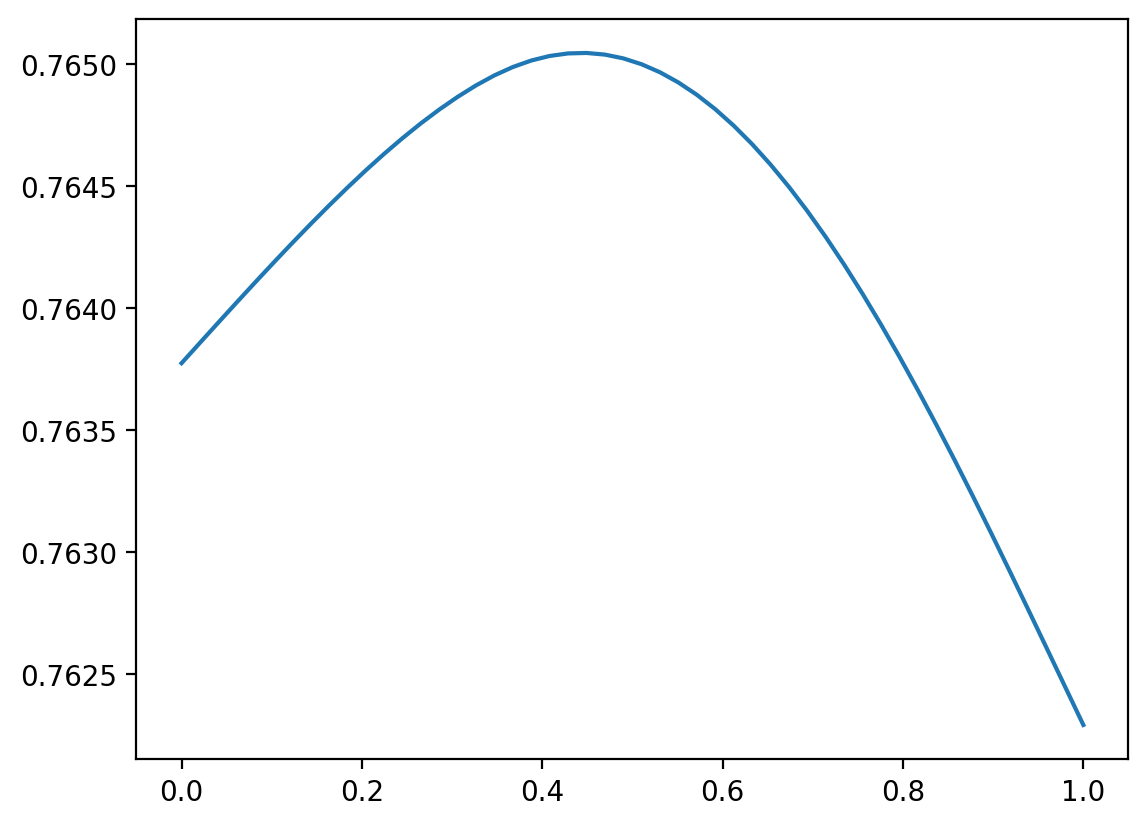

In [45]:
m = list(game.miners.values())[3]
Xs_pplns = [wealth_process(Lam * (H + m.h) / env.H, b * m.h * (1 - fee_function(H)) / (H + m.h), m.c, 0, 1) for H in np.linspace(0, env.H, 50)]

X_pps1 = wealth_process(Lam * m.h / d1, b * (1 - fpps1) * d1, m.c, 0, 1)
print(X_pps1.V(m.x, q)[1])
X_pps2 = wealth_process(Lam * m.h / d2, b * (1 - fpps2) * d2, m.c, 0, 1)
print(X_pps2.V(m.x, q)[1])
X_pps3 = wealth_process(Lam * m.h / d3, b * (1 - fpps3) * d3, m.c, 0, 1)
print(X_pps3.V(m.x, q)[1])
obj = [X_pplns.V(m.x, q)[1] for X_pplns in Xs_pplns]
# print(X_pps1.E(m.x) - 0.5 * m.gamma * X_pps1.Var())
# obj = [X_pplns.E(m.x) - 0.5 * m.gamma * X_pplns.Var() for X_pplns in Xs_pplns]
plt.plot(np.linspace(0, env.H, 50), obj)

In [41]:
# game.run_formation()
game.assignment
list(game.pplns_pools.values())[1].H

0.2768556512361121

In [42]:
print(game.run_best_response())
game.assignment
# 
# list(game.pplns_pools.values())[0].H

True


{1: ('pps', 'pps 2'),
 2: ('pps', 'pps 2'),
 3: ('pps', 'pps 2'),
 4: ('pps', 'pps 3'),
 5: ('pps', 'pps 2'),
 6: ('pps', 'pps 2'),
 7: ('pps', 'pps 2'),
 8: ('pps', 'pps 3'),
 9: ('pps', 'pps 2'),
 10: ('pps', 'pps 3')}

In [660]:

print(list(game.pplns_pools.values())[0].H, list(game.pplns_pools.values())[0].f)
np.array([m.h / list(game.pplns_pools.values())[0].H for m in list(game.pplns_pools.values())[0].members])


0.7729191781389105 0.02987020279674643


array([0.20356649, 0.00138934, 0.13798296, 0.0190465 , 0.40804859,
       0.09153478, 0.06494461, 0.07348673])

In [141]:
unpooled = [game.miners[i] for i, a in game.assignment.items() if a == ("pps", "solo")]
k = 5
# game.propose_founding([unpooled[0], unpooled[1]])
group =[game.miners[7], game.miners[10]]
H = sum(m.h for m in group)
fee = game.fee_function(H) if len(group) >= 2 else 0.0
gains = {}
fee, H
for m in group:
    rate = game.env.Lam * H / game.env.H
    jump = game.env.b * (1 - fee) * m.h / H
    gains[m.idx] = game.engine.score(m, rate, jump) - game.current_payoff(m)
    X_pplns = wealth_process(Lam * H / env.H, (1-fee)*b* m.h / H, m.c, 0, 1)
    print(X_pplns.V(m.x, q)[1])
gains

0.7248554242514418
0.8039218293467507


{7: 0.0, 10: 0.0}

In [49]:
# game.payoff_at(miner= game.miners[0], target: Tuple[str, str])
game.pps_pools, game.pplns_pools
targets = [("pps", name) for name in game.pps_pools]




[[0.02609380916615678, 0.26078060895555377],
 [-0.032195514810828496, 0.8454716000145845],
 [0.004063670438253113, 0.05617525478328345],
 [0.09372359261617302, 1.022146448306631],
 [0.00874104940170628, 0.06028628850140798]]

In [36]:
print("after formation:", {i: a for i, a in game.assignment.items()})

print("after formation:", {i: a for i, a in game.assignment.items()})
print("nash stable:", game.is_nash_stable())
# perturb with an attractive PPS entrant and re-equilibrate
game.introduce_pps(PPS_Pool(f=0.02, delta=0.1, name="pps_entrant"))
game.run_best_response()
print("after entrant:", {i: a for i, a in game.assignment.items()})
print("nash stable:", game.is_nash_stable())

after formation: {1: ('pplns', 'pplns_1'), 2: ('pplns', 'pplns_1'), 3: ('pplns', 'pplns_1'), 4: ('pplns', 'pplns_1'), 5: ('pplns', 'pplns_1')}
after formation: {1: ('pplns', 'pplns_1'), 2: ('pplns', 'pplns_1'), 3: ('pplns', 'pplns_1'), 4: ('pplns', 'pplns_1'), 5: ('pplns', 'pplns_1')}
nash stable: True
after entrant: {1: ('pps', 'pps_entrant'), 2: ('pps', 'pps_entrant'), 3: ('pps', 'pps_entrant'), 4: ('pps', 'pps_entrant'), 5: ('pps', 'pps_entrant')}
nash stable: True


In [18]:
import random
from typing import Callable, Dict, List, Optional, Tuple

class Miner:
    def __init__(self, h: float, c: float, x: float, idx: int, gamma: float = None):
        self.h = h
        self.c = c
        self.x = x  # Initialize ruin probability threshold attribute
        self.gamma = gamma  # Initialize risk aversion attribute
        self.div = {}  # Initialize dividend attribute
        self.utility = {}  # Initialize mean-variance utility attribute
        self.best_div = 0.0
        self.best_utility = 0.0
        self.idx = idx  # Assign a unique index to each miner

class PPLNS_Pool:
    __slots__ = ("members", "H", "fee_function", "f")
    def __init__(self, members: List[Miner], fee_function: Callable[[float], float]):
        self.members: set = set(members) if members else set()
        self.H = sum(miner.h for miner in members)
        self.f = fee_function(self.H)

    def add(self, miner) -> None:
        self.members.add(miner)
        self.H += miner.h
        self.f = self.fee_function(self.H) if self.fee_function else 0.0
    
    def remove(self, miner) -> None:
        self.members.discard(miner)
        self.H -= miner.h
        self.f = self.fee_function(self.H) if self.fee_function else 0.0

class PPS_Pool:
    __slots__ = ("f", "delta", "name")
    def __init__(self, f: float = 0.0, delta: float = 1, name: str = None):
        self.f = f
        self.delta = delta
        self.name = name
        
class blockchain_network:
    def __init__(self, Lam, b, q):
        self.Lam = Lam
        self.b = b
        self.q = q
        self.n = 0
        self.H = 0
        self.miners = []
        self.pps_pools = []
        self.partition = None  # List of the pools

    def add_miner(self, miner):
        self.n += 1
        self.H += miner.h
        self.miners.append(miner)

    def add_pps_pool(self, pps_pool):
        self.pps_pools.append(pps_pool)
        for miner in self.miners:
            X_PPS = wealth_process(self.Lam * miner.h / self.H / pps_pool.delta, 
                               self.b * (1 - pps_pool.f) * pps_pool.delta, 
                                         miner.c, 0, 1)
            miner.div[pps_pool.name] = X_PPS.V(miner.x, self.q)[1]

    def add_pplns_pool(self, pplns_pool):
        for miner in self.pplns_pool.members:
            X_PPLNS = wealth_process(self.Lam * pplns_pool.H / self.H , 
                                       self.b * (1 - pplns_pool.f) *miner.h / pplns_pool.H, 
                                                 miner.c, 0, 1)
            miner.best_div = X_PPLNS.V(miner.x, self.q)[1]

        

In [19]:
Lam, b, q = 1, 3.125, 0.03
main_net = blockchain_network(Lam=Lam, b=b, q=q)

In [20]:
np.random.seed(0)
n = 5
alphas = np.ones(n) 
hs = np.random.dirichlet(alphas)
mus = hs * Lam
# etas = np.random.uniform(0, 1, n) # random values for the etas
etas = np.random.uniform(0.1, 0.3, n) # set the etas to 0.5 for all miners
# etas = 0.1 * np.ones(n)  # set the etas to 0.5 for all miners
cs = mus * b / (1 + etas)
Xs_solo = [wealth_process(mu, b, c, 0, 1) for mu, c in zip(mus, cs)] # Define the wealth process for a solo miner 
betas = np.random.uniform(0, 1, n)  # Define the ruin probability threshold
# betas = 0.5*np.ones(n)  # Set the ruin probability threshold to 0.5 for all miners
xs = np.array([sc.optimize.root_scalar(lambda x: X_solo.ruin_proba(x) - beta, bracket=[0.001, 1000], method='bisect').root for X_solo, beta in zip(Xs_solo, betas)])

for h, c, x in zip(hs, cs, xs):
    main_net.add_miner(Miner(h=h, c=c, x=x, idx=len(main_net.miners)+1))
main_net.add_pps_pool(PPS_Pool(f=0.0, delta=1, name="Solo"))

In [22]:
# Random disjoint partition of all miners in main_net.miners
rng = np.random.default_rng(421)

miners_arr = np.array(main_net.miners, dtype=object)
n_miners = len(miners_arr)

# choose a random number of groups between 2 and n_miners
n_groups = int(rng.integers(2, n_miners + 1))

# shuffle miners, then split at random cut points
perm = rng.permutation(n_miners)
cut_points = np.sort(rng.choice(np.arange(1, n_miners), size=n_groups - 1, replace=False))
partition_miners = [grp.tolist() for grp in np.split(miners_arr[perm], cut_points)]

for i, miners in enumerate(partition_miners):

    pplns_pool_i = PPLNS_Pool(members=miners, 
                              fee_function=lambda H: f0 + (fmax - f0) * np.power(H / main_net.H, gamma))
    # main_net.add_pplns_pool(pplns_pool_i)

In [438]:
class PPLNS_Pool:
    

    def __init__(self, members: Optional[set] = None, fee_function: Callable[[float], float] = None, name: str = None):
        self.members: set = set(members) if members else set()
        self.H = sum(miner.h for miner in self.members)
        self.fee_function = fee_function
        self.f = fee_function(self.H) if fee_function else 0.0
        self.name = name

    def add(self, miner) -> None:
        self.members.add(miner)
        self.H += miner.h
        self.f = self.fee_function(self.H) if self.fee_function else 0.0

    def remove(self, miner) -> None:
        self.members.discard(miner)
        self.H -= miner.h
        self.f = self.fee_function(self.H) if self.fee_function else 0.0

    def __len__(self) -> int:
        return len(self.members)

In [439]:
# Random disjoint partition of all miners in main_net.miners
rng = np.random.default_rng(421)

miners_arr = np.array(main_net.miners, dtype=object)
n_miners = len(miners_arr)

# choose a random number of groups between 2 and n_miners
n_groups = int(rng.integers(2, n_miners + 1))

# shuffle miners, then split at random cut points
perm = rng.permutation(n_miners)
cut_points = np.sort(rng.choice(np.arange(1, n_miners), size=n_groups - 1, replace=False))
partition_miners = [grp.tolist() for grp in np.split(miners_arr[perm], cut_points)]
f0, fmax, gamma = 0.00, 0.05, 1/4
for i, miners in enumerate(partition_miners):

    pplns_pool_i = PPLNS_Pool(members=miners, 
                              fee_function=lambda H: f0 + (fmax - f0) * np.power(H / main_net.H, gamma), name=f"PPLNS Pool #{i+1}")
    main_net.add_pplns_pool(pplns_pool_i)

AttributeError: 'blockchain_network' object has no attribute 'add_pplns_pool'

In [415]:

        
    
    # def add_pps_pool(self, pps_pool):
    #     self.m += 1
    #     self.pps_pools.append(pps_pool)
    #     for miner in self.miners:
    #         if miner.h * self.Lam / self.H * self.b * (1-pps_pool.f) - miner.c < 0:
    #             # print(f"Warning: Miner {miner.name} has negative expected profit in PPS pool {pps_pool.name}.")
    #             miner.div[pps_pool.name] = - np.inf  # Assign negative infinity to indicate unprofitable participation
    #         else:
    #             X_pps_pool = wealth_process(miner.h * self.Lam / self.H / pps_pool.delta, self.b * (1-pps_pool.f) * pps_pool.delta, miner.c, 0, 1)
    #             miner.div[pps_pool.name] = X_pps_pool.V(miner.x, q)[1]
        

    # def add_pplns_pool(self, pplns_pool):
    #         self.m += 1
    #         self.pplns_pools.append(pplns_pool)
    #         for miner in pplns_pool.members:
    #             if self.Lam / self.H * self.b * (1-pplns_pool.f) * miner.h -  miner.c < 0:
    #                 # print(f"Warning: Miner {miner.name} has negative expected profit in PPLNS pool {pplns_pool.name}.")
    #                 miner.div[pplns_pool.name] = - np.inf  # Assign negative infinity to indicate unprofitable participation
    #             else:
    #                 X_pplns_pool = wealth_process(pplns_pool.H * self.Lam / self.H, 
    #                                           self.b * (1-pplns_pool.f) * miner.h / pplns_pool.H, miner.c,
    #                                           0, 1)
    #                 miner.div[pplns_pool.name] = X_pplns_pool.V(miner.x, q)[1]
            



        
# class pps_pool:
#     def __init__(self, delta, f, name):
        
#         self.miners = []
#         self.total_hash_power = 0
#         self.delta = delta # Difficulty reduction parameter for the pool
#         self.f = f # Management fee
#         self.name = name
#     def add_miner(self, miner):
#         self.miners.append(miner)
#         self.total_hash_power += miner.h

class pplns_pool:
    __slots__ = ("members", "H", "fee_function", "f", "name")

    def __init__(self, members: Optional[set] = None, fee_function: Callable[[float], float] = None, name: str = None):
        self.members: set = set(members) if members else set()
        self.H = sum(miner.h for miner in self.members)
        self.fee_function = fee_function
        self.f = fee_function(self.H) if fee_function else 0.0
        self.name = name
        

    def add(self, miner) -> None:
        self.members.add(miner)
        self.H += miner.h
        self.f = self.fee_function(self.H) if self.fee_function else 0.0

    def remove(self, miner) -> None:
        self.members.discard(miner)
        self.H -= miner.h
        self.f = self.fee_function(self.H) if self.fee_function else 0.0

    def __len__(self) -> int:
        return len(self.members)
         
    

In [420]:
[m.div for m in partition_miners[1]]

[{'solo': 2.266036736953068, 'PPLNS Pool #2': 2.2626004846679404},
 {'solo': 6.89568189187296, 'PPLNS Pool #2': 6.892395211112399},
 {'solo': 3.8100507314521046, 'PPLNS Pool #2': 3.8052335885826074},
 {'solo': 10.799811479546191, 'PPLNS Pool #2': 10.798084637650959},
 {'solo': 3.2782272653414384, 'PPLNS Pool #2': 3.274088574792624},
 {'solo': 0.46936986525056734, 'PPLNS Pool #2': 0.46723297922108736},
 {'solo': 0.2936956699397042, 'PPLNS Pool #2': 0.2909152032607992}]

In [361]:
# Choose a random subset of miners to form a PPLNS pool
np.random.seed(421)
for k in range(15):  # Create 5 random PPLNS pools
    subset_size = np.random.randint(2, len(main_net.miners))
    subset_miners = np.random.choice(main_net.miners, size=subset_size, replace=False).tolist()

    
    random_pplns_pool = pplns_pool(
        miners=subset_miners,
        fee_function=lambda H: f0 + (fmax - f0) * np.power(H / main_net.H, gamma),
        name="Random PPLNS Pool "+str(k+1)
    )
    main_net.add_pplns_pool(random_pplns_pool)

    print(f"Pool size: {subset_size} miners")
    print(f"Pool hash power: {random_pplns_pool.H:.4f}")
    print(f"Pool fee: {random_pplns_pool.f:.4f}")

Pool size: 89 miners
Pool hash power: 0.8879
Pool fee: 0.0485
Pool size: 40 miners
Pool hash power: 0.4301
Pool fee: 0.0405
Pool size: 72 miners
Pool hash power: 0.7417
Pool fee: 0.0464
Pool size: 80 miners
Pool hash power: 0.8356
Pool fee: 0.0478
Pool size: 51 miners
Pool hash power: 0.5208
Pool fee: 0.0425
Pool size: 67 miners
Pool hash power: 0.6652
Pool fee: 0.0452
Pool size: 96 miners
Pool hash power: 0.9504
Pool fee: 0.0494
Pool size: 33 miners
Pool hash power: 0.3760
Pool fee: 0.0392
Pool size: 66 miners
Pool hash power: 0.6796
Pool fee: 0.0454
Pool size: 20 miners
Pool hash power: 0.2439
Pool fee: 0.0351
Pool size: 96 miners
Pool hash power: 0.9506
Pool fee: 0.0494
Pool size: 57 miners
Pool hash power: 0.5941
Pool fee: 0.0439
Pool size: 99 miners
Pool hash power: 0.9919
Pool fee: 0.0499
Pool size: 33 miners
Pool hash power: 0.3362
Pool fee: 0.0381
Pool size: 5 miners
Pool hash power: 0.0392
Pool fee: 0.0223


In [ ]:
# Create a first PPS pool
pool1 = pps_pool(delta=0.2, f=0.005, name="PPS Pool #1")
main_net.add_pps_pool(pool1)

In [372]:
# for pplns_pool in main_net.pplns_pools:
pplns_pool1 = main_net.pplns_pools[0]

for miner in  pplns_pool.miners:
    print(np.all(miner.div[pplns_pool1.name] >= np.array(list(miner.div.values()))))

False
False
False
False
False


In [362]:
np.array(list(main_net.miners[1].div.values()))
main_net.miners[1].div
# join_pps_pool = sum(np.array([(miner.div['solo'] < miner.div['PPS Pool #1']) & (miner.div['Random PPLNS Pool'] < miner.div['PPS Pool #1']) for miner in main_net.miners]))
# join_pps_pool

{'solo': 2.266036736953068,
 'PPS Pool #1': 2.2661699012241954,
 'Random PPLNS Pool 1': 2.2695829426749494,
 'Random PPLNS Pool 3': 2.268459160008049,
 'Random PPLNS Pool 6': 2.267821060418021,
 'Random PPLNS Pool 7': 2.2700278524665007,
 'Random PPLNS Pool 10': 2.2637106834617495,
 'Random PPLNS Pool 11': 2.270029197344647,
 'Random PPLNS Pool 12': 2.2671942092477004,
 'Random PPLNS Pool 13': 2.2703121029674165}

In [283]:
f0, fmax, gamma = 0.00, 0.04, 1/3
for k in range(1, len(main_net.miners)):
    pplns_pool_k = pplns_pool(miners=main_net.miners[1:(k+1)], fee_function=lambda H: f0 + (fmax - f0) * np.power(H / main_net.H, gamma), name="PPLNS Pool #"+str(k+1))
    main_net.add_pplns_pool(pplns_pool_k)

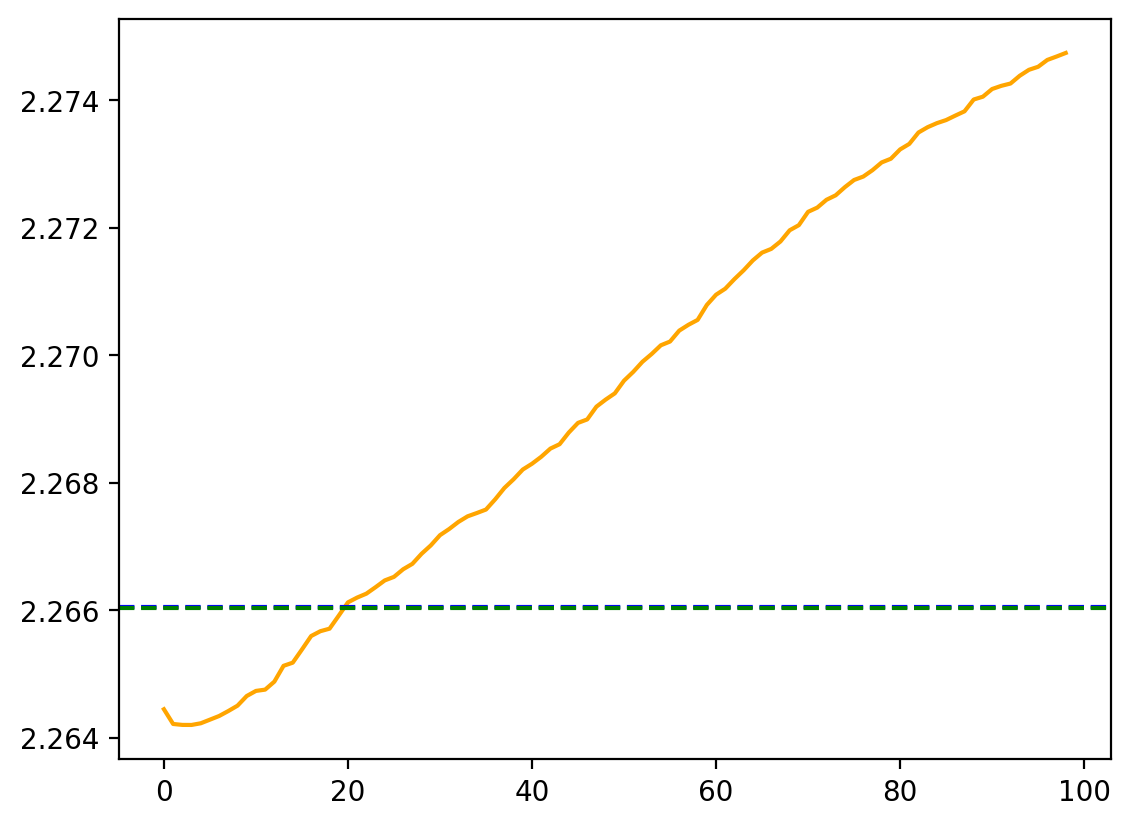

In [284]:
pplns_div = np.array([main_net.miners[1].div["PPLNS Pool #"+str(k+1)] for k in range(1,len(main_net.miners))])
plt.plot(pplns_div, label='PPLNS Dividends', color='orange')
plt.axhline(main_net.miners[1].div["PPS Pool #1"], color='blue', linestyle='--', label='PPS Dividends')
plt.axhline(main_net.miners[1].div["solo"], color='green', linestyle='--', label='Solo Dividends')

In [195]:
# Create a first miner
h1, h2 = 0.01, 0.02
c1, c2 = h1 * Lam * b / (1 + 0.1), h2 * Lam * b / (1 + 0.2)  # Example costs based on hash power and some efficiency factor
miner1 = miner(h=h1, c=c1, x=2)
miner2 = miner(h=h2, c=c2, x=3)

In [196]:

print(miner1.div)
main_net.add_miner(miner2)
print(miner1.div, miner2.div)
[miner.h for miner in main_net.miners]


{'solo': 104.8953221520618}
{'solo': 35.10716890581358} {'solo': 69.96496705815666}


[0.01, 0.02]

In [198]:
# Create a first PPS pool
pool1 = pps_pool(delta=0.3, f=0.05, name="PPS Pool #1")
main_net.add_pps_pool(pool1)


In [199]:
print(miner1.div, miner2.div)

{'solo': 35.10716890581358, 'PPS Pool #1': 33.770503970322565} {'solo': 69.96496705815666, 'PPS Pool #1': 66.952976056391}


In [207]:
f0, fmax = 0.00, 0.01
pplns_pool1 = pplns_pool(miners=[miner1, miner2], fee_function=lambda H: f0 + (fmax - f0) * np.power(H / main_net.H, gamma), name="PPLNS Pool #1")
main_net.add_pplns_pool(pplns_pool1)

In [208]:
print(miner1.div, miner2.div)

{'solo': 35.10716890581358, 'PPS Pool #1': 33.770503970322565, 'PPLNS Pool #1': 35.134903905231056} {'solo': 69.96496705815666, 'PPS Pool #1': 66.952976056391, 'PPLNS Pool #1': 69.47193777427616}


In [80]:
from scipy.optimize import minimize_scalar
f0, fmax, gamma = 0, 0.04, 1.0
c, h, x =cs[0], hs[0], xs[0]
divs_opt, Hs_opt = [], []
for c, h, x in zip(cs, hs, xs):e
    def div_pplns_func(H):
        f = fee_power_family(H+h, f0, fmax, gamma)
        X_pplns = wealth_process(Lam * (H+h), (1-f) * b * h / (H+h), c, 0, 1)
        return X_pplns.V(x, q, acc=0.01)[1]
    res = minimize_scalar(lambda H: -div_pplns_func(H), bounds=(0, 1-h), method='bounded')
    div_opt, H_opt = -res.fun, res.x
    divs_opt.append(div_opt)
    Hs_opt.append(H_opt)


np.array(Hs_opt)

array([0.56056286, 0.7940982 , 0.73861638, 0.83363296, 0.65149228,
       0.92671676, 0.98716438, 0.45120284, 0.87280007, 0.47098956,
       0.98286034, 0.77056771, 0.91963815, 0.53714128, 0.47658532,
       0.85568654, 0.72295354, 0.98301953, 0.99408639, 0.99691786,
       0.98450527, 0.39009681, 0.90610596, 0.93167513, 0.9928022 ,
       0.66834599, 0.61526953, 0.42627583, 0.19195976, 0.98905189,
       0.98760679, 0.98885251, 0.65792905, 0.92975838, 0.35254356,
       0.85431433, 0.99613881, 0.98868517, 0.71043674, 0.99023899,
       0.59751794, 0.99341672, 0.99206239, 0.99055805, 0.96435744,
       0.98640699, 0.66540073, 0.99591041, 0.94530134, 0.17799655,
       0.72452324, 0.48821555, 0.9891972 , 0.83930802, 0.85797284,
       0.96476029, 0.74813776, 0.47440779, 0.99245046, 0.55131778,
       0.85946015, 0.58618833, 0.42252848, 0.98694298, 0.9879297 ,
       0.98628858, 0.98910189, 0.99472907, 0.70755267, 0.3848643 ,
       0.78178912, 0.5896331 , 0.47597241, 0.31278371, 0.99324

In [ ]:
Lam ,b = 6, 3.125 # block discovery rate of the network and reward for finding a block
H = 1 # Total hashpower of the netwwork
h = 0.1
c = h * Lam * b / 1.2  # operational cost per time unit (profitability on average)
X_solo = wealth_process(h * Lam, b, c, 0 , 1) # Define the wealth process for a solo miner
# PPS pools
fs = np.array([0.005, 0.01, 0.03])  # pool fees
deltas = np.array([0.7, 0.3, 0.1])  # difficulty reduction
lams= Lam * h / deltas # arrival rates of the pools
bs = b * (1 - fs) * deltas  # rewards after pool fees
X_pps = [wealth_process(lam, b, c, 0, 1 ) for lam, b in zip(lams, bs)] # Define the wealth

beta = 0.5  # Define the ruin probability threshold
x = sc.optimize.root_scalar(lambda x: X_solo.ruin_proba(x) - beta, bracket=[0.01, 1000], method='bisect').root # initial wealth of the miner
print(x)

# Compute the expected value of the wealth process at time T=1
# X_solo_1.E(x), X_solo_1.Var()
q = 0.03 # Define the discount rate
# X_solo_1.V(x,q)[1]

div_pps = [X.V(x, q)[1] for X in X_pps]
# print("Expected values of the wealth process when solo mining:", X_solo.E(x))
# print("Expected values of the wealth process when pps mining:", [X.E(x) for X in X_pps])
# print("Variance of the wealth process when solo mining:", X_solo.Var() )

# print("Variance of the wealth process when pps mining:", [X.Var() for X in X_pps])
# print("Expected discounted dividend when solo mining:", X_solo.V(x, q)[1] )
# print("Expected discounted dividend when pps mining:", div_pps)

rows = [{
    "pool": "solo",
    "fee": 0.0,
    "difficulty reduction": 1.0,
    "reward arrival rate": h * Lam,
    "reward size": b,
    "expected discounted dividend": X_solo.V(x, q)[1],
}]

rows += [{
    "pool": f"PPS #{i+1}",
    "fee": float(fs[i]),
    "difficulty reduction": float(deltas[i]),
    "reward arrival rate": float(lams[i]),
    "reward size": float(bs[i]),
    "expected discounted dividend": float(div_pps[i]),
} for i in range(len(fs))]
df_characteristics = pd.DataFrame(rows)[["pool", "fee", "difficulty reduction"]].copy()
df_characteristics.columns = ["Pool", "Management Fee", "Difficulty Reduction"]

df_rewards = pd.DataFrame(rows)[["pool", "reward arrival rate", "reward size", "expected discounted dividend"]].copy()
df_rewards.columns = ["Pool", "Reward Arrival Rate", "Reward Size", "Expected Discounted Dividend"]

latex_table_1 = df_characteristics.to_latex(index=False, float_format="%.3f")
latex_table_2 = df_rewards.to_latex(index=False, float_format="%.3f")

print("Pool Characteristics:")
print(latex_table_1)
print("\nReward and Dividend:")
print(latex_table_2)


5.754161256505919
Pool Characteristics:
\begin{tabular}{lrr}
\toprule
Pool & Management Fee & Difficulty Reduction \\
\midrule
solo & 0.000 & 1.000 \\
PPS #1 & 0.005 & 0.700 \\
PPS #2 & 0.010 & 0.300 \\
PPS #3 & 0.030 & 0.100 \\
\bottomrule
\end{tabular}


Reward and Dividend:
\begin{tabular}{lrrr}
\toprule
Pool & Reward Arrival Rate & Reward Size & Expected Discounted Dividend \\
\midrule
solo & 0.600 & 3.125 & 7.891 \\
PPS #1 & 0.857 & 2.177 & 8.250 \\
PPS #2 & 2.000 & 0.928 & 9.552 \\
PPS #3 & 6.000 & 0.303 & 10.578 \\
\bottomrule
\end{tabular}



# Combining two pools? 

In [20]:
fs = np.array([0, 0.005, 0.01, 0.03])  # pool fees
deltas = np.array([1, 0.7, 0.3, 0.1])  # difficulty reduction
lams= Lam * h / deltas # arrival rates of the pools
bs = b * (1 - fs) * deltas  # rewards after pool fees

prec = Decimal('0.001')  # precision for the position
res = {}
m_comb_max = 2
m = 3
for comb in itertools.combinations(range(m+1), m_comb_max):
    w = np.array([1 / 2, 1 / 2])
    X_mixed = wealth_process(lams[np.array(comb)], bs[np.array(comb)], c, 1, w)
    res_max_scalar = max_scalar(X_mixed, x, q)
    res_max_scalar['position'][res_max_scalar['position'] > 1 - prec] = 1
    res_max_scalar['position'][res_max_scalar['position'] < prec] = 0
    res[comb] = res_max_scalar
res
    

{(0, 1): {'position': array([0., 1.]), 'value': 8.250050206013865},
 (0, 2): {'position': array([0., 1.]), 'value': 9.551578168934803},
 (0, 3): {'position': array([0., 1.]), 'value': 10.57791579664647},
 (1, 2): {'position': array([0., 1.]), 'value': 9.551582008986149},
 (1, 3): {'position': array([0., 1.]), 'value': 10.577918565499656},
 (2, 3): {'position': array([0., 1.]), 'value': 10.577931372488557}}

# Adding One PPLNS pool

[0.85714286 2.         6.        ] [0.6        0.65454545 0.70909091 0.76363636 0.81818182 0.87272727
 0.92727273 0.98181818 1.03636364 1.09090909 1.14545455 1.2
 1.25454545 1.30909091 1.36363636 1.41818182 1.47272727 1.52727273
 1.58181818 1.63636364 1.69090909 1.74545455 1.8        1.85454545
 1.90909091 1.96363636 2.01818182 2.07272727 2.12727273 2.18181818
 2.23636364 2.29090909 2.34545455 2.4        2.45454545 2.50909091
 2.56363636 2.61818182 2.67272727 2.72727273 2.78181818 2.83636364
 2.89090909 2.94545455 3.         3.05454545 3.10909091 3.16363636
 3.21818182 3.27272727 3.32727273 3.38181818 3.43636364 3.49090909
 3.54545455 3.6        3.65454545 3.70909091 3.76363636 3.81818182
 3.87272727 3.92727273 3.98181818 4.03636364 4.09090909 4.14545455
 4.2        4.25454545 4.30909091 4.36363636 4.41818182 4.47272727
 4.52727273 4.58181818 4.63636364 4.69090909 4.74545455 4.8
 4.85454545 4.90909091 4.96363636 5.01818182 5.07272727 5.12727273
 5.18181818 5.23636364 5.29090909 5.34545

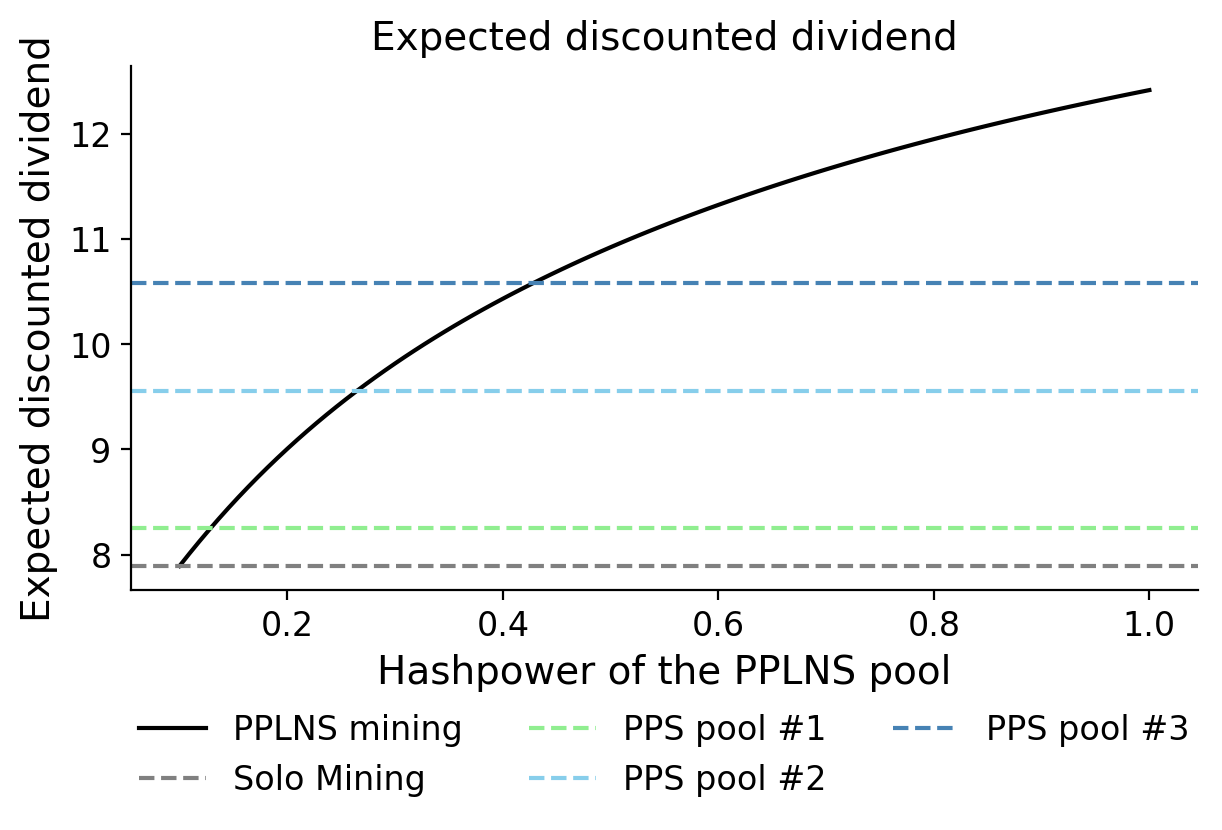

In [29]:
Lam ,b = 6, 3.125 # block discovery rate of the network and reward for finding a block
H = 1 # Total hashpower of the netwwork
h = 0.1
Hs_pplns = np.linspace(0, 1 - h, 100) # Hashpower of mining pool 1 (pplns)
c = h * Lam * b / 1.2  # operational cost per time unit (profitability on average)
X_solo = wealth_process(h * Lam, b, c, 0, 1) # Define the wealth process for a solo miner
f_pplns = 0.00 # Define the fee for PPLNS mining
X_pplns = [wealth_process((H_pplns + h) * Lam, h * b* (1- f_pplns) / (H_pplns + h), c, 0, 1) for H_pplns in Hs_pplns] # Define the wealth
# process for a PPLNS miner
fs = np.array([0.005, 0.01, 0.03])  # pool fees
deltas = np.array([0.7, 0.3, 0.1])  # difficulty reduction
lams= Lam * h / deltas # arrival rates of the pools
print(lams, (Hs_pplns + h) * Lam)

bs = b * (1 - fs) * deltas  # rewards after pool fees
print(bs, h * b* (1- f_pplns) / (Hs_pplns + h))

X_pps = [wealth_process(lam, b, c, 0, 1 ) for lam, b in zip(lams, bs)] # Define the wealth

beta = 0.5  # Define the ruin probability threshold
x = sc.optimize.root_scalar(lambda x: X_solo.ruin_proba(x) - beta, bracket=[0.01, 1000], method='bisect').root # initial wealth of the miner

# Compute the expected value of the wealth process at time T=1
# X_solo_1.E(x), X_solo_1.Var()
q = 0.03 # Define the discount rate
# X_solo_1.V(x,q)[1]
div_pplns = [X.V(x, q)[1] for X in X_pplns]
div_pps = [X.V(x, q)[1] for X in X_pps]
print("Expected values of the wealth process when solo mining:", X_solo.E(x))
print("Expected values of the wealth process when pplns mining:", [X.E(x) for X in X_pplns])
print("Expected values of the wealth process when pps mining:", [X.E(x) for X in X_pps])
print("Variance of the wealth process when solo mining:", X_solo.Var() )
print("Variance of the wealth process when pplns mining:", [X.Var() for X in X_pplns])
print("Variance of the wealth process when pps mining:", [X.Var() for X in X_pps])
print("Expected discounted dividend when solo mining:", X_solo.V(x, q)[1] )
print("Expected discounted dividend when pplns mining:", div_pplns)
print("Expected discounted dividend when pps mining:", div_pps)

palette = ["#808080", "#90EE90", "#87CEEB", "#4682B4"]

plt.plot(Hs_pplns + h, div_pplns, label="PPLNS mining", color="black")
plt.axhline(y=X_solo.V(x, q)[1], linestyle="--", label="Solo Mining", color=palette[0])

for i, pps in enumerate(div_pps):
    plt.axhline(y=pps, linestyle="--", label=f"PPS pool #{i+1}", color=palette[i+1])

plt.xlabel("Hashpower of the PPLNS pool", fontsize=14)
plt.ylabel("Expected discounted dividend", fontsize=14)
plt.title("Expected discounted dividend", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=3,
    frameon=False,
    fontsize=12
)

sns.despine()

plt.tight_layout(rect=(0, 0.08, 1, 1))
dropbox_path = Path("/Users/pgoffard/Dropbox/Collab/Albrecher-Fouque-Goffard/Figures")
# output_path = "../figures/pplns_dividend.pdf"
plt.gcf().savefig(dropbox_path / "pplns_dividend.pdf", bbox_inches="tight")
plt.show()

